# Assignment: LightGBM vs XGBoost on Diabetes Dataset

## Objective
The objective of this assignment is to compare the performance of LightGBM and XGBoost algorithms using the Diabetes Dataset.

## Tasks Performed
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Building
- Hyperparameter Tuning
- Cross Validation
- Model Evaluation
- Comparative Analysis

## Dataset
Pima Indians Diabetes Dataset

In [1]:
# Install Required Libraries

!pip install lightgbm xgboost -q

In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [3]:
# Load Dataset

df = pd.read_csv("diabetes (1).csv")

# Display first 5 rows

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Shape of Dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 768
Columns : 9


In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Statistical Summary

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Missing Value Analysis


In [7]:
# Check Missing Values

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
# In Diabetes Dataset,
# zeros in these columns are invalid and treated as missing values

cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[cols] = df[cols].replace(0, np.nan)

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [9]:
# Impute Missing Values using Median

imputer = SimpleImputer(strategy='median')

df[cols] = imputer.fit_transform(df[cols])

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### The assignment instruction mentions loading the Titanic dataset for EDA. However, since the objective of this project is to build a model on the Diabetes dataset, I have performed the EDA on the Diabetes data to maintain a consistent and logical machine learning pipeline.

# Exploratory Data Analysis (EDA)

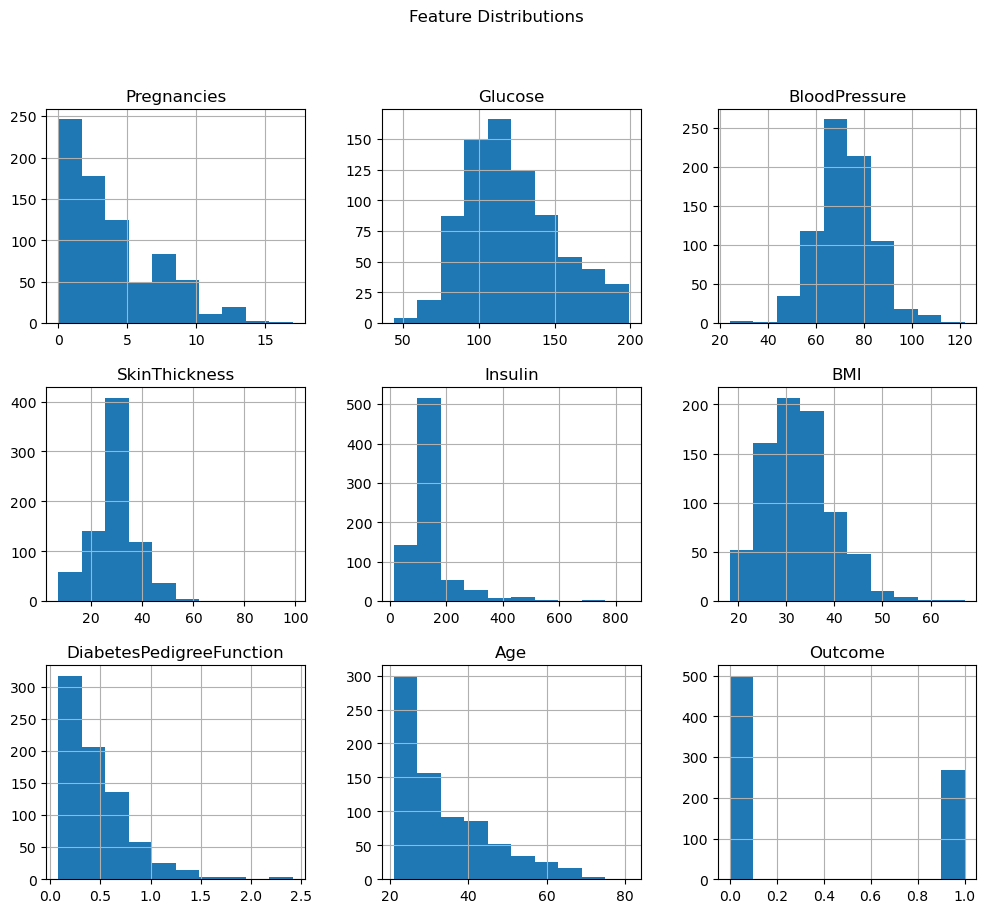

In [10]:
# Histogram

df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

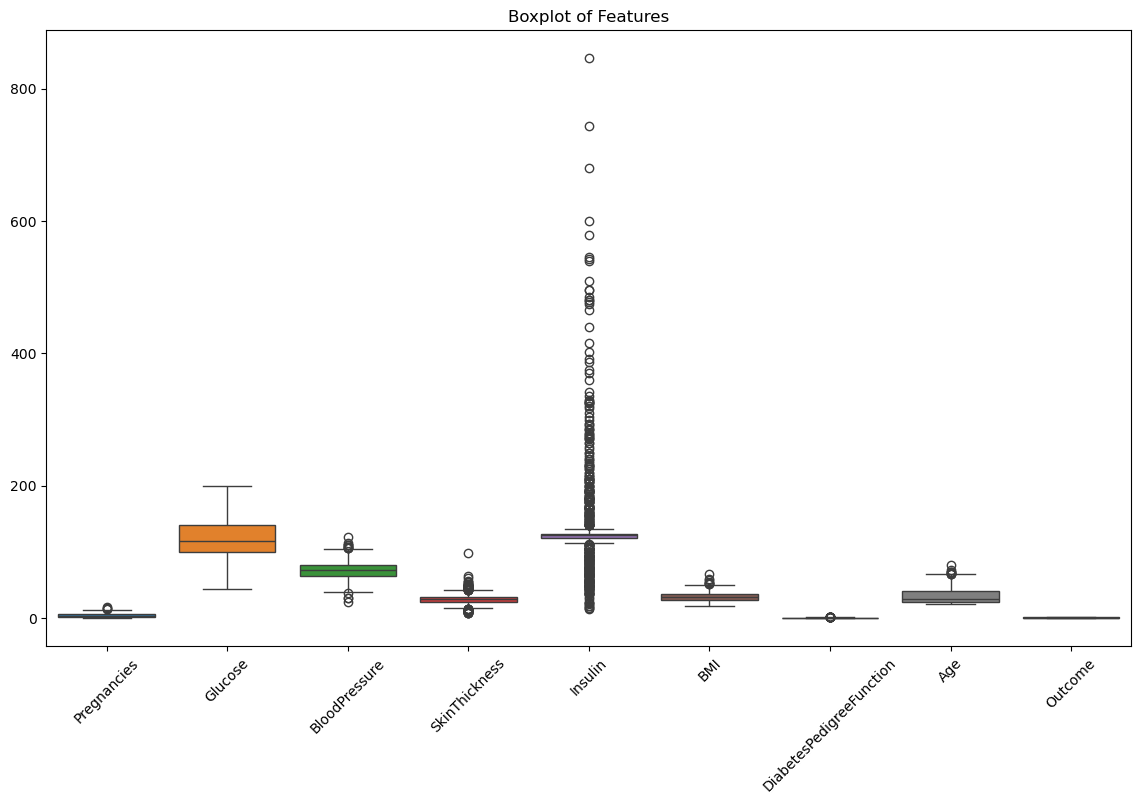

In [11]:
# Boxplots

plt.figure(figsize=(14,8))

sns.boxplot(data=df)

plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

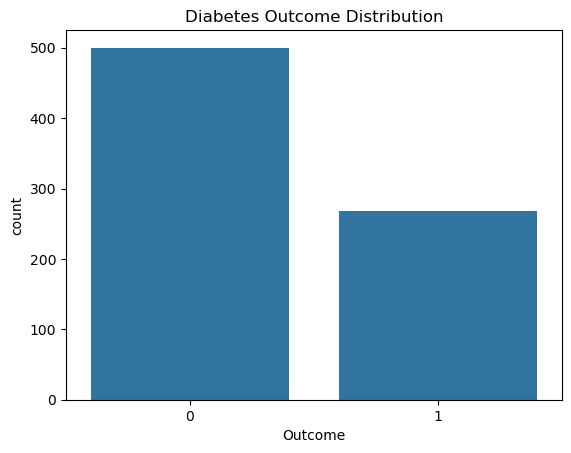

In [12]:
# Outcome Distribution

sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Outcome Distribution")
plt.show()

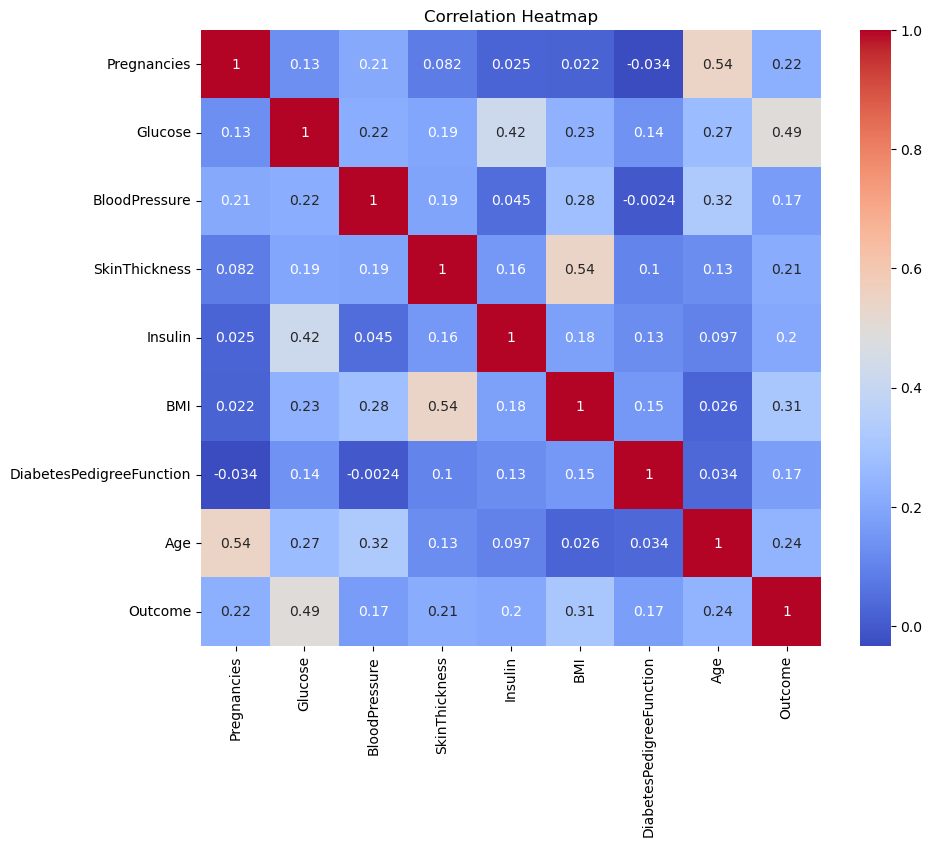

In [13]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

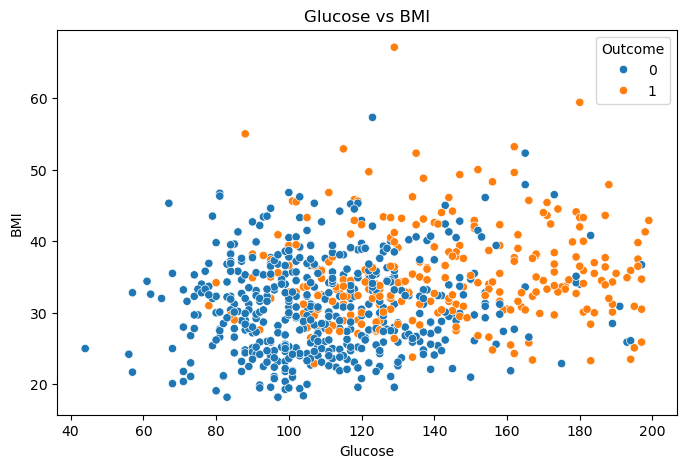

In [14]:
# Scatter Plot

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.title("Glucose vs BMI")
plt.show()

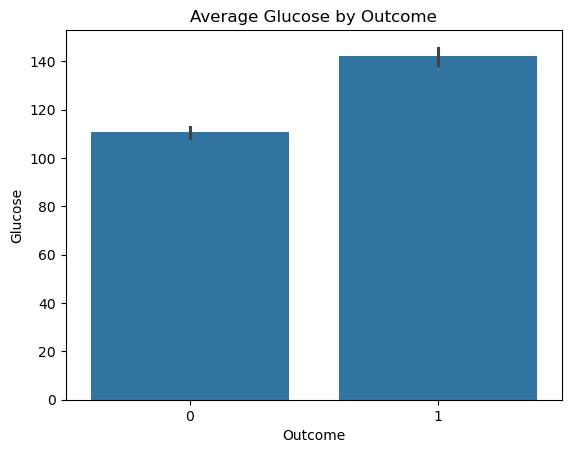

In [15]:
# Bar Plot

sns.barplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.title("Average Glucose by Outcome")
plt.show()

# Feature Selection

In [17]:
# Features and Target

X = df.drop('Outcome', axis=1)

y = df['Outcome']

print(X.shape)
print(y.shape)

(768, 8)
(768,)


# Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (614, 8)
Testing Shape : (154, 8)


# LightGBM Model

In [19]:
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [20]:
print("LightGBM Results")

print("Accuracy :", accuracy_score(y_test,lgbm_pred))
print("Precision :", precision_score(y_test,lgbm_pred))
print("Recall :", recall_score(y_test,lgbm_pred))
print("F1 Score :", f1_score(y_test,lgbm_pred))

LightGBM Results
Accuracy : 0.7662337662337663
Precision : 0.68
Recall : 0.6296296296296297
F1 Score : 0.6538461538461539


In [21]:
print(classification_report(y_test,lgbm_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       100
           1       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



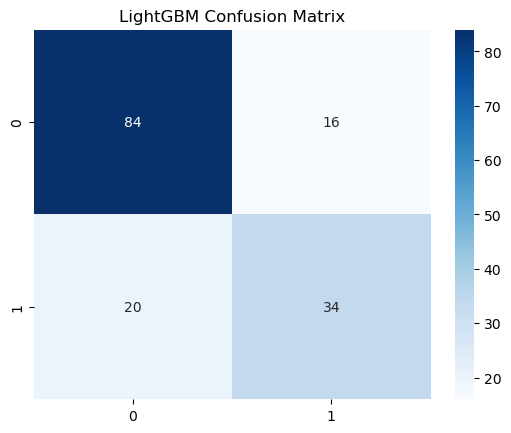

In [22]:
cm = confusion_matrix(y_test,lgbm_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LightGBM Confusion Matrix")
plt.show()

# XGBoost Model

In [23]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

In [24]:
print("XGBoost Results")

print("Accuracy :", accuracy_score(y_test,xgb_pred))
print("Precision :", precision_score(y_test,xgb_pred))
print("Recall :", recall_score(y_test,xgb_pred))
print("F1 Score :", f1_score(y_test,xgb_pred))

XGBoost Results
Accuracy : 0.7597402597402597
Precision : 0.673469387755102
Recall : 0.6111111111111112
F1 Score : 0.6407766990291263


In [25]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



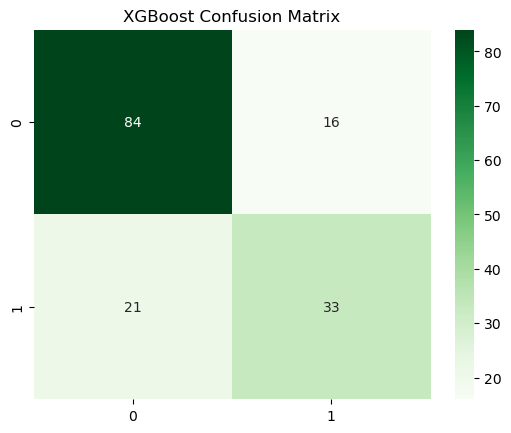

In [27]:
cm = confusion_matrix(y_test,xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("XGBoost Confusion Matrix")
plt.show()

# Hyperparameter Tuning

In [28]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7]
}

grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print("Best Parameters")
print(grid.best_params_)

Best Parameters
{'max_depth': 3, 'n_estimators': 100}


# Cross Validation

In [29]:
lgbm_cv = cross_val_score(
    lgbm,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

xgb_cv = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("LightGBM CV Accuracy :", lgbm_cv.mean())
print("XGBoost CV Accuracy :", xgb_cv.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

# Comparative Analysis

In [30]:
results = pd.DataFrame({
    'Model':['LightGBM','XGBoost'],
    'Accuracy':[
        accuracy_score(y_test,lgbm_pred),
        accuracy_score(y_test,xgb_pred)
    ],
    'Precision':[
        precision_score(y_test,lgbm_pred),
        precision_score(y_test,xgb_pred)
    ],
    'Recall':[
        recall_score(y_test,lgbm_pred),
        recall_score(y_test,xgb_pred)
    ],
    'F1 Score':[
        f1_score(y_test,lgbm_pred),
        f1_score(y_test,xgb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.766234,0.680000,0.629630,0.653846
1,XGBoost,0.759740,0.673469,0.611111,0.640777


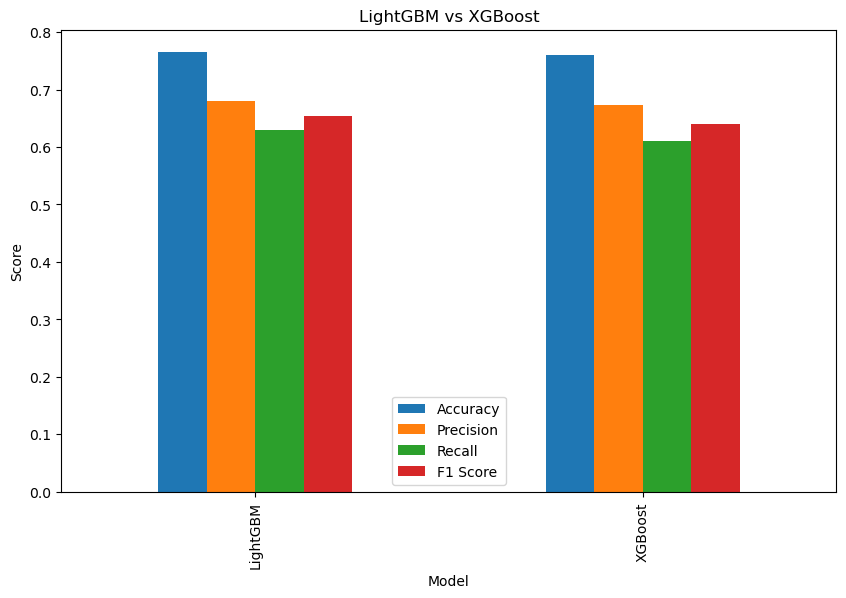

In [31]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("LightGBM vs XGBoost")
plt.ylabel("Score")
plt.show()

# Conclusion

1. Both LightGBM and XGBoost were trained on the Diabetes Dataset.

2. Missing values were handled using median imputation.

3. Histograms, boxplots, scatter plots and heatmaps were used for EDA.

4. Hyperparameter tuning and cross-validation were performed to improve model performance.

5. Accuracy, Precision, Recall and F1-score were used for evaluation.

6. The model with the higher F1-score and Accuracy is considered the better performer for this dataset.

7. LightGBM is generally faster and memory efficient.

8. XGBoost often provides slightly better predictive performance but may require more computation time.

9. The final choice depends on the business requirement and computational resources.

# Interview Questions

### 1. What is the difference between LightGBM and XGBoost?

LightGBM uses leaf-wise tree growth and is faster, while XGBoost uses level-wise tree growth and is generally more stable.

---

### 2. Why is F1 Score important?

F1 Score balances Precision and Recall and is useful for imbalanced datasets.

---

### 3. What is Cross Validation?

Cross Validation evaluates model performance on multiple train-test splits to improve reliability.

---

### 4. Why do we perform Hyperparameter Tuning?

To find the optimal model parameters and improve prediction accuracy.

---

### 5. What is the role of Gradient Boosting?

Gradient Boosting combines weak learners sequentially to reduce prediction errors.

---

### 6. Why replace zeros with NaN in Diabetes Dataset?

Certain features cannot realistically be zero, so they are treated as missing values.